In [26]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler # normalize data 
from keras.callbacks import ModelCheckpoint # save the best model trained 
from tensorflow.keras.models import load_model 
from keras.models import Sequential # input  
from keras.layers import LSTM 
from keras.layers import Dropout # avoid unactively learning 
from keras.layers import Dense # output 

from sklearn.metrics import r2_score 
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import mean_absolute_percentage_error 

In [27]:
df = pd.read_csv("../Dataset_NCKH/vnm.csv")
df 

,Ngày,Đóng cửa,Mở cửa,Cao nhất,Thấp nhất,KL,% Thay đổi
0,21/07/2023,"73,500.0","72,500.0","75,000.0","72,400.0",3.12M,1.10%
1,20/07/2023,"72,700.0","72,600.0","72,900.0","72,300.0",2.45M,0.14%
2,19/07/2023,"72,600.0","72,500.0","73,000.0","72,400.0",2.95M,0.28%
3,18/07/2023,"72,400.0","72,500.0","72,600.0","72,200.0",2.93M,0.14%
4,17/07/2023,"72,300.0","73,000.0","73,600.0","72,200.0",3.92M,-1.36%
...,...,...,...,...,...,...,...
2500,16/07/2013,"96,528.0","95,139.0","97,222.0","95,139.0",729.69K,1.46%
2501,15/07/2013,"95,139.0","95,139.0","95,833.0","94,444.0",176.98K,0.00%
2502,12/07/2013,"95,139.0","94,444.0","95,139.0","93,750.0",220.82K,0.74%
2503,11/07/2013,"94,444.0","94,444.0","95,139.0","93,750.0",161.84K,0.00%


In [28]:
df['Ngày'] = pd.to_datetime(df['Ngày'], format='%d/%m/%Y')

In [29]:
df.shape

(2505, 7)

In [30]:
df.head()

,Ngày,Đóng cửa,Mở cửa,Cao nhất,Thấp nhất,KL,% Thay đổi
0,2023-07-21,"73,500.0","72,500.0","75,000.0","72,400.0",3.12M,1.10%
1,2023-07-20,"72,700.0","72,600.0","72,900.0","72,300.0",2.45M,0.14%
2,2023-07-19,"72,600.0","72,500.0","73,000.0","72,400.0",2.95M,0.28%
3,2023-07-18,"72,400.0","72,500.0","72,600.0","72,200.0",2.93M,0.14%
4,2023-07-17,"72,300.0","73,000.0","73,600.0","72,200.0",3.92M,-1.36%


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2505 entries, 0 to 2504
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Ngày        2505 non-null   datetime64[ns]
 1   Đóng cửa    2505 non-null   object        
 2   Mở cửa      2505 non-null   object        
 3   Cao nhất    2505 non-null   object        
 4   Thấp nhất   2505 non-null   object        
 5   KL          2505 non-null   object        
 6   % Thay đổi  2505 non-null   object        
dtypes: datetime64[ns](1), object(6)
memory usage: 137.1+ KB


In [32]:
df.describe()

,Ngày
count,2505
mean,2018-07-17 16:17:14.730539008
min,2013-07-10 00:00:00
25%,2016-01-13 00:00:00
50%,2018-07-19 00:00:00
75%,2021-01-14 00:00:00
max,2023-07-21 00:00:00


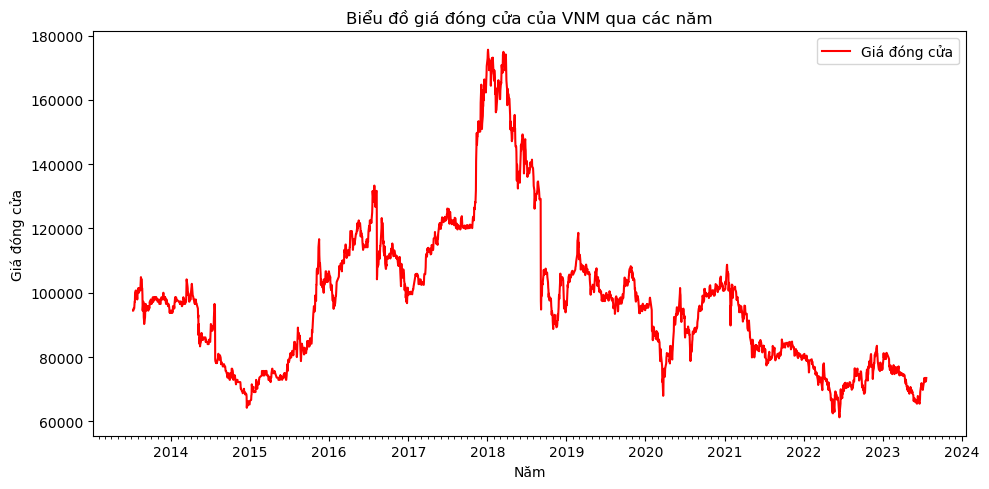

In [33]:
from matplotlib.dates import YearLocator, DateFormatter, MonthLocator 
df['Ngày'] = pd.to_datetime(df['Ngày'], format='%d/%m/%Y') 
df = df.sort_values(by='Ngày') 
df['Đóng cửa'] = df['Đóng cửa'].str.replace(',', '').astype(float)
df['Mở cửa'] = df['Mở cửa'].str.replace(',', '').astype(float)
df['Cao nhất'] = df['Cao nhất'].str.replace(',', '').astype(float)
df['Thấp nhất'] = df['Thấp nhất'].str.replace(',', '').astype(float)
# Get year from df['year']
df['Năm'] = df['Ngày'].dt.year 
plt.figure(figsize=(10,5)) 
plt.plot(df['Ngày'], df['Đóng cửa'], label='Giá đóng cửa', color='red')
plt.xlabel('Năm')
plt.ylabel('Giá đóng cửa')
plt.title('Biểu đồ giá đóng cửa của VNM qua các năm')
plt.legend(loc='best') 
# Định dạng đồ thị hiển thị các ngày theo năm tháng 
years = YearLocator() 
yearsFmt = DateFormatter('%Y') 
months = MonthLocator() # Thêm dòng này để khai báo MonthLocator 
plt.gca().xaxis.set_major_locator(years)
plt.gca().xaxis.set_major_formatter(yearsFmt)
plt.gca().xaxis.set_minor_locator(months)
plt.tight_layout() 
plt.show() 

In [34]:
df1 = pd.DataFrame(df, columns=['Ngày', 'Đóng cửa'])
df1.index = df1['Ngày']
df1.drop('Ngày', axis=1, inplace=True)
df1

,Đóng cửa
Ngày,
2013-07-10,94444.0
2013-07-11,94444.0
2013-07-12,95139.0
2013-07-15,95139.0
2013-07-16,96528.0
...,...
2023-07-17,72300.0
2023-07-18,72400.0
2023-07-19,72600.0


In [ ]:
data = df1.values 
train_data = data[:1500] 
text_data = data[1500:] 

In [36]:
data

array([[94444.],
       [94444.],
       [95139.],
       ...,
       [72600.],
       [72700.],
       [73500.]])

In [37]:
sc = MinMaxScaler(feature_range=(0,1))
sc_train = sc.fit_transform(data)

In [38]:
x_train, y_train = [], [] 
for i in range(50, len(train_data)): 
  x_train.append(sc_train[i-50:i, 0]) # lấy 50 giá trị đóng cửa liên tục 
  y_train.append(sc_train[i,0]) # lấy ra giá đóng cửa ngày hôm sau 

In [39]:
x_train 

[array([0.29027738, 0.29027738, 0.29635691, 0.29635691, 0.30850724,
        0.31457803, 0.31457803, 0.33887869, 0.34494948, 0.34494948,
        0.32672836, 0.33279915, 0.33887869, 0.32065757, 0.32672836,
        0.34494948, 0.34494948, 0.35102902, 0.33887869, 0.35102902,
        0.34494948, 0.34494948, 0.34494948, 0.34494948, 0.35709981,
        0.36925013, 0.38140046, 0.37532967, 0.37532967, 0.35102902,
        0.35102902, 0.33279915, 0.29027738, 0.31457803, 0.30850724,
        0.27205626, 0.26598547, 0.25383514, 0.27205626, 0.29027738,
        0.30850724, 0.30850724, 0.29027738, 0.3024277 , 0.3024277 ,
        0.29635691, 0.3024277 , 0.29635691, 0.29635691, 0.29027738]),
 array([0.29027738, 0.29635691, 0.29635691, 0.30850724, 0.31457803,
        0.31457803, 0.33887869, 0.34494948, 0.34494948, 0.32672836,
        0.33279915, 0.33887869, 0.32065757, 0.32672836, 0.34494948,
        0.34494948, 0.35102902, 0.33887869, 0.35102902, 0.34494948,
        0.34494948, 0.34494948, 0.34494948, 0.

In [40]:
y_train 

[0.2963569134842401,
 0.30242770379791795,
 0.2963569134842401,
 0.30242770379791795,
 0.3145780319617488,
 0.30850724164807086,
 0.3145780319617488,
 0.32065756981190174,
 0.30850724164807086,
 0.3145780319617488,
 0.30850724164807086,
 0.3145780319617488,
 0.3145780319617488,
 0.3145780319617488,
 0.3267283601255797,
 0.3145780319617488,
 0.3145780319617488,
 0.32065756981190174,
 0.3267283601255797,
 0.3267283601255797,
 0.32065756981190174,
 0.3267283601255797,
 0.3267283601255797,
 0.32065756981190174,
 0.32065756981190174,
 0.3267283601255797,
 0.3267283601255797,
 0.32065756981190174,
 0.32065756981190174,
 0.32065756981190174,
 0.3145780319617488,
 0.3145780319617488,
 0.3145780319617488,
 0.32065756981190174,
 0.32065756981190174,
 0.3145780319617488,
 0.30850724164807086,
 0.30850724164807086,
 0.30850724164807086,
 0.30850724164807086,
 0.30850724164807086,
 0.32065756981190174,
 0.3267283601255797,
 0.3267283601255797,
 0.32065756981190174,
 0.32065756981190174,
 0.32065756

In [41]:
x_train = np.array(x_train)
y_train = np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1],1))
y_train = np.reshape(y_train, (y_train.shape[0], 1)) 

In [42]:
model = Sequential() 
model.add(LSTM(units=120, input_shape=(x_train.shape[1], 1), return_sequences=True))
model.add(LSTM(units=64))
model.add(Dropout(0.5)) # eliminate some record to avoid unactively learning (overfitting) 
model.add(Dense(1)) 
model.compile(loss='mean_absolute_error', optimizer='adam')

c:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
save_model = "../Dataset_NCKH/lstm_model.keras" 
best_model = ModelCheckpoint(save_model, monitor='loss', verbose=2, save_best_only=True, mode='auto')
model.fit(x_train, y_train, epochs=100, batch_size=50, verbose=2, callbacks=[best_model]) 

Epoch 1/100

Epoch 1: loss improved from inf to 0.10867, saving model to ../Dataset_NCKH/lstm_model.keras
29/29 - 3s - 105ms/step - loss: 0.1087
Epoch 2/100

Epoch 2: loss improved from 0.10867 to 0.05646, saving model to ../Dataset_NCKH/lstm_model.keras
29/29 - 1s - 26ms/step - loss: 0.0565
Epoch 3/100

Epoch 3: loss improved from 0.05646 to 0.05309, saving model to ../Dataset_NCKH/lstm_model.keras
29/29 - 1s - 25ms/step - loss: 0.0531
Epoch 4/100

Epoch 4: loss improved from 0.05309 to 0.05105, saving model to ../Dataset_NCKH/lstm_model.keras
29/29 - 1s - 23ms/step - loss: 0.0510
Epoch 5/100

Epoch 5: loss did not improve from 0.05105
29/29 - 1s - 22ms/step - loss: 0.0518
Epoch 6/100

Epoch 6: loss improved from 0.05105 to 0.04890, saving model to ../Dataset_NCKH/lstm_model.keras
29/29 - 1s - 23ms/step - loss: 0.0489
Epoch 7/100

Epoch 7: loss did not improve from 0.04890
29/29 - 1s - 23ms/step - loss: 0.0495
Epoch 8/100

Epoch 8: loss improved from 0.04890 to 0.04494, saving model t

In [44]:
y_train = sc.inverse_transform(y_train)
final_model = load_model("../Dataset_NCKH/lstm_model.keras")
y_train_predict = final_model.predict(x_train) 
y_train_predict = sc.inverse_transform(y_train_predict)

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [45]:
test = df1[len(train_data)-50:].values 
test = test.reshape(-1,1) 
sc_test = sc.transform(test)
x_test = [] 
for i in range(50, test.shape[0]): 
  x_test.append(sc_test[i-50:i,0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1],1))

y_test = data[1500:] 
y_test_predict = final_model.predict(x_test)
y_test_predict = sc.inverse_transform(y_test_predict) 

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [46]:
y_test_predict

array([[ 99328.586],
       [ 99242.31 ],
       [100313.57 ],
       ...,
       [ 73088.37 ],
       [ 73162.445],
       [ 73301.62 ]], dtype=float32)

In [47]:
y_test_predict.shape

(1005, 1)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20152\1183999064.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data1['Dự đoán'] = y_train_predict
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20152\1183999064.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data1['Dự đoán'] = y_test_predict


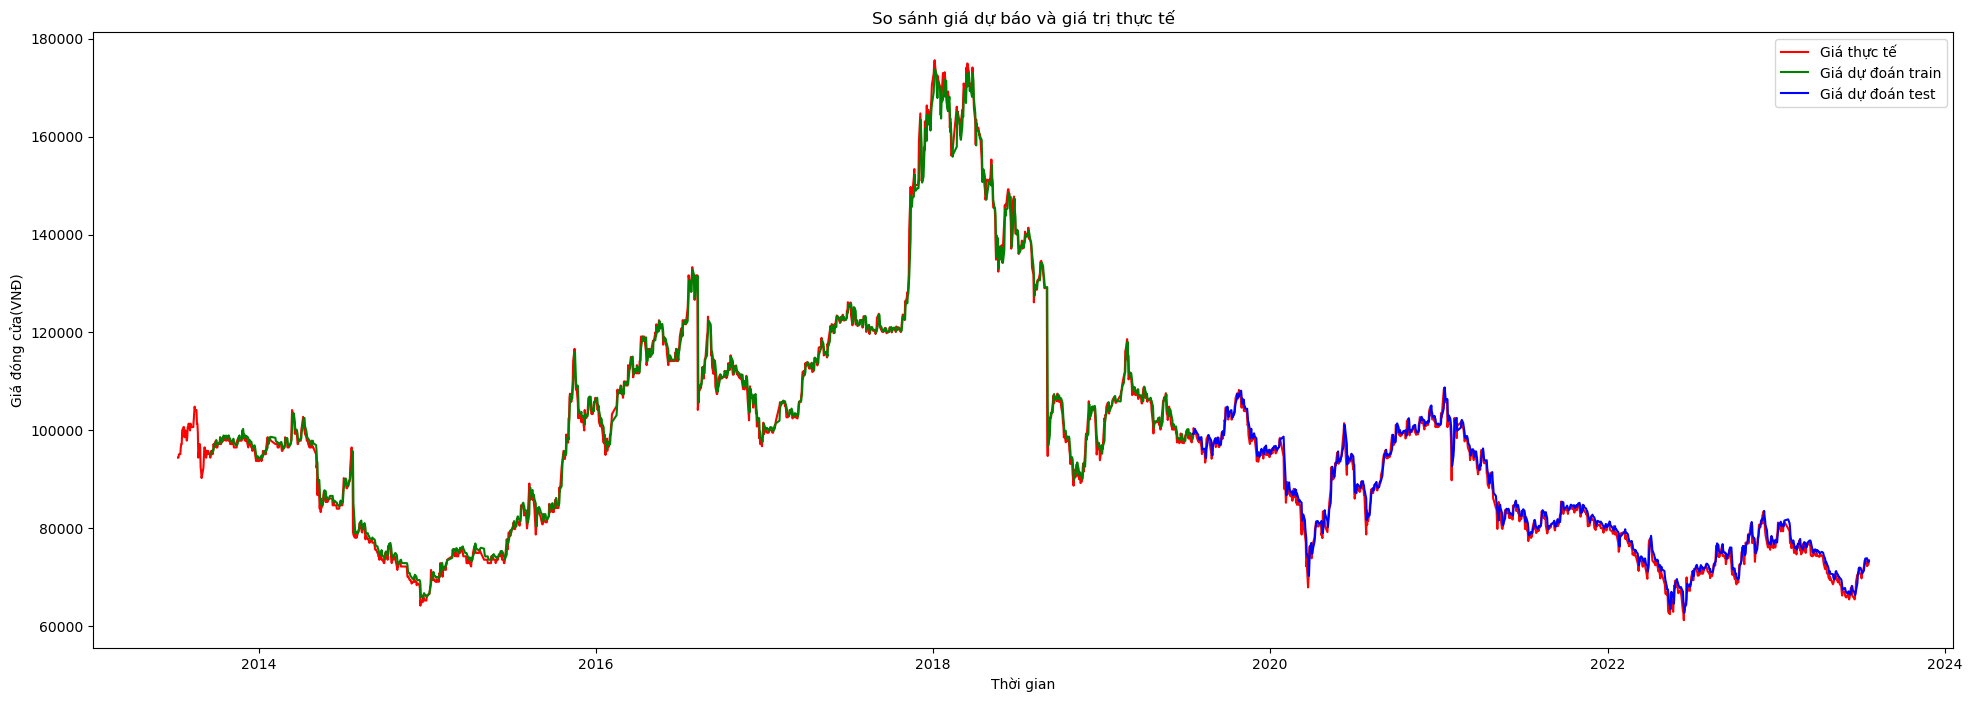

In [48]:
train_data1 = df1[50:1500]
test_data1 = df1[1500:] 
plt.figure(figsize=(24,8))
plt.plot(df1, label='Giá thực tế', color='red')
train_data1['Dự đoán'] = y_train_predict 
plt.plot(train_data1['Dự đoán'], label='Giá dự đoán train', color='green')
test_data1['Dự đoán'] = y_test_predict 
plt.plot(test_data1['Dự đoán'], label='Giá dự đoán test', color='blue')
plt.title('So sánh giá dự báo và giá trị thực tế') 
plt.xlabel('Thời gian')
plt.ylabel('Giá đóng cửa(VNĐ)')
plt.legend() 
plt.show() 

In [49]:
print('Độ phù hợp tập train:', r2_score(y_train, y_train_predict)) # r2 
print('Sai số tuyệt đối trung bình trên tập train (VNĐ):', mean_absolute_error(y_train, y_train_predict))
print('Phần trăm sai số tuyệt đối trung bình tập train:', mean_absolute_percentage_error(y_train, y_train_predict)) 

Độ phù hợp tập train: 0.9926496784314895
Sai số tuyệt đối trung bình trên tập train (VNĐ): 1253.9568426724134
Phần trăm sai số tuyệt đối trung bình tập train: 0.011848530153266803


In [50]:
train_data1

,Đóng cửa,Dự đoán
Ngày,,
2013-09-19,95139.0,95099.218750
2013-09-20,95833.0,95364.781250
2013-09-23,95139.0,96011.226562
2013-09-24,95833.0,95783.500000
2013-09-25,97222.0,96054.039062
...,...,...
2019-07-11,99133.0,99322.476562
2019-07-12,98183.0,99475.062500
2019-07-15,97549.0,98869.796875


In [51]:
print('Độ phù hợp tập train:', r2_score(y_test, y_test_predict)) # r2 
print('Sai số tuyệt đối trung bình trên tập train (VNĐ):', mean_absolute_error(y_test, y_test_predict))
print('Phần trăm sai số tuyệt đối trung bình tập train:', mean_absolute_percentage_error(y_test, y_test_predict)) 

Độ phù hợp tập train: 0.9824129738406886
Sai số tuyệt đối trung bình trên tập train (VNĐ): 1131.7479897388057
Phần trăm sai số tuyệt đối trung bình tập train: 0.01381176285408523


In [52]:
test_data1

,Đóng cửa,Dự đoán
Ngày,,
2019-07-18,98658.0,99328.585938
2019-07-19,100479.0,99242.312500
2019-07-22,99371.0,100313.570312
2019-07-23,99291.0,100031.695312
2019-07-24,99450.0,99714.890625
...,...,...
2023-07-17,72300.0,73900.906250
2023-07-18,72400.0,73347.312500
2023-07-19,72600.0,73088.367188
